  STEP 1 : Loading Dataset
  Shape           : (500, 53)
  Columns         : ['sar_id', 'filing_date', 'institution_name', 'branch_name', 'branch_city', 'primary_regulator', 'contact_office', 'law_enforcement_notified', 'customer_id', 'customer_name', 'account_number', 'date_of_birth', 'occupation', 'customer_type', 'kyc_risk', 'relationship_years', 'address', 'country', 'activity_start_date', 'activity_end_date', 'total_amount', 'number_of_transactions', 'international_transfer_flag', 'high_risk_geo_flag', 'avg_transaction_amount', 'max_transaction_amount', 'unique_counterparties', 'velocity_score', 'structuring_flag', 'rapid_movement_flag', 'layering_flag', 'mule_account_flag', 'deviation_score', 'previous_alerts', 'previous_sar_flag', 'historical_risk_score', 'profile_deviation_flag', 'fraud_category', 'typology_matched', 'triggered_rules', 'explainability_notes', 'supporting_evidence', 'loss_amount', 'material_impact_flag', 'amount_recovered', 'analyst_name', 'analyst_title', 'anal

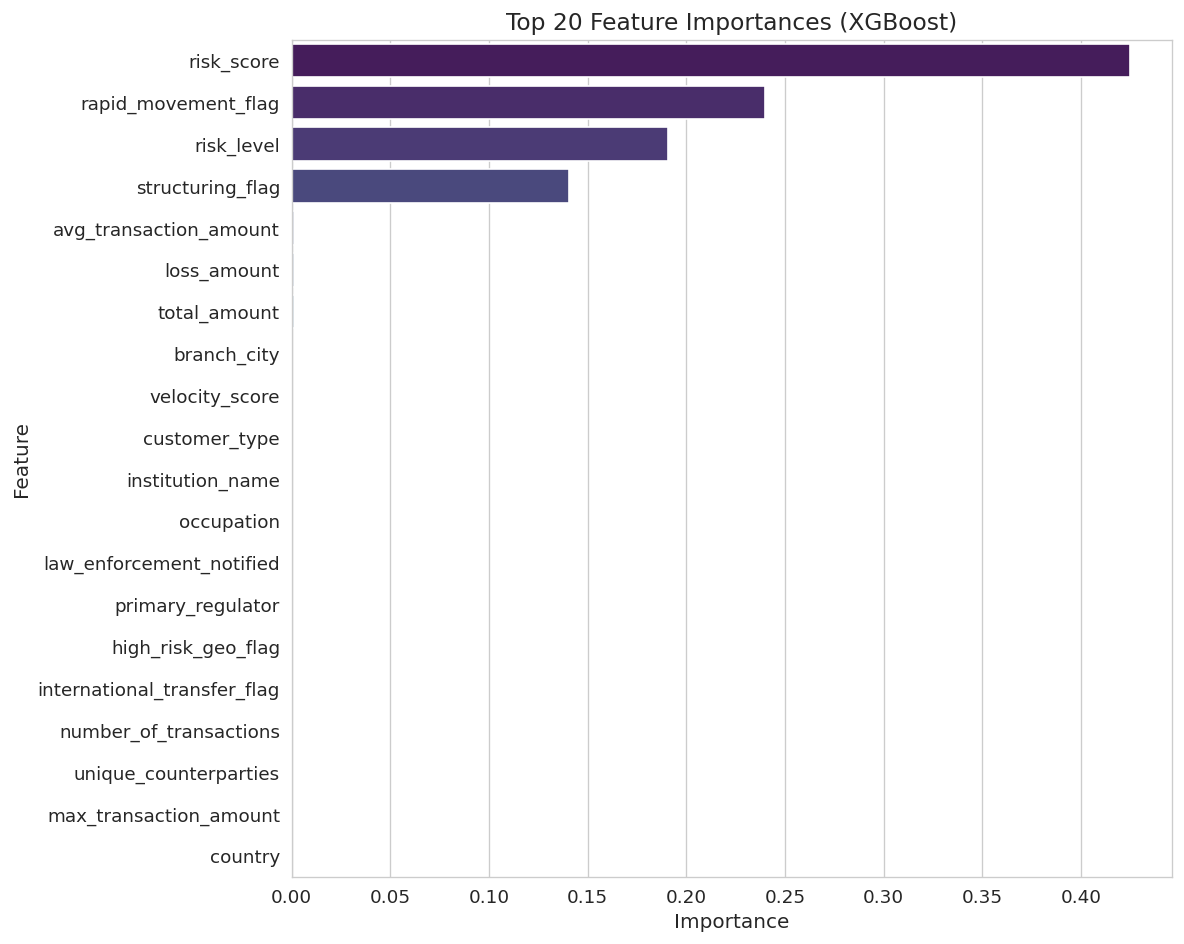

  📊 Feature importance plot saved → feature_importance.png

  STEP 11 : Confusion Matrix


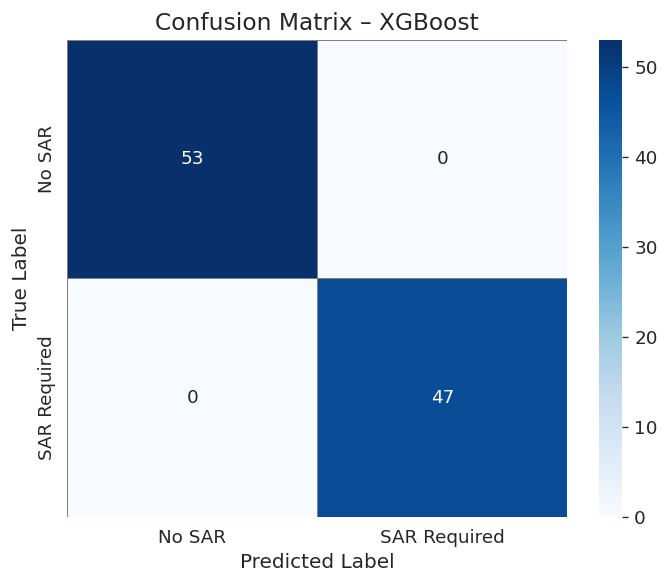

  📊 Confusion matrix saved → confusion_matrix.png

  STEP 12 : ROC Curve


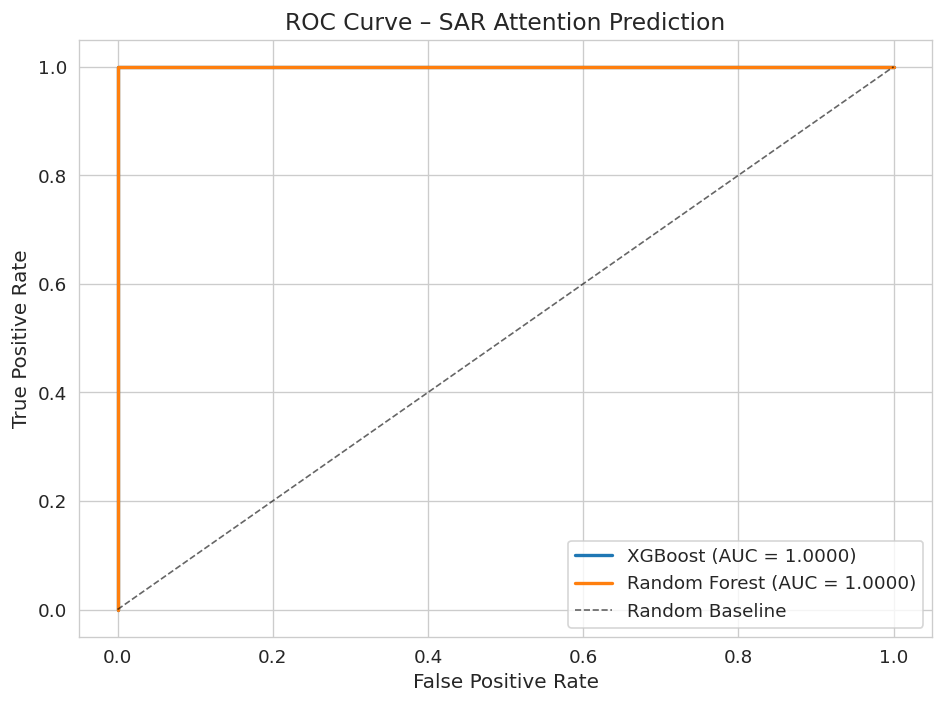

  📊 ROC curve saved → roc_curve.png

  STEP 13 : Precision‑Recall Curve


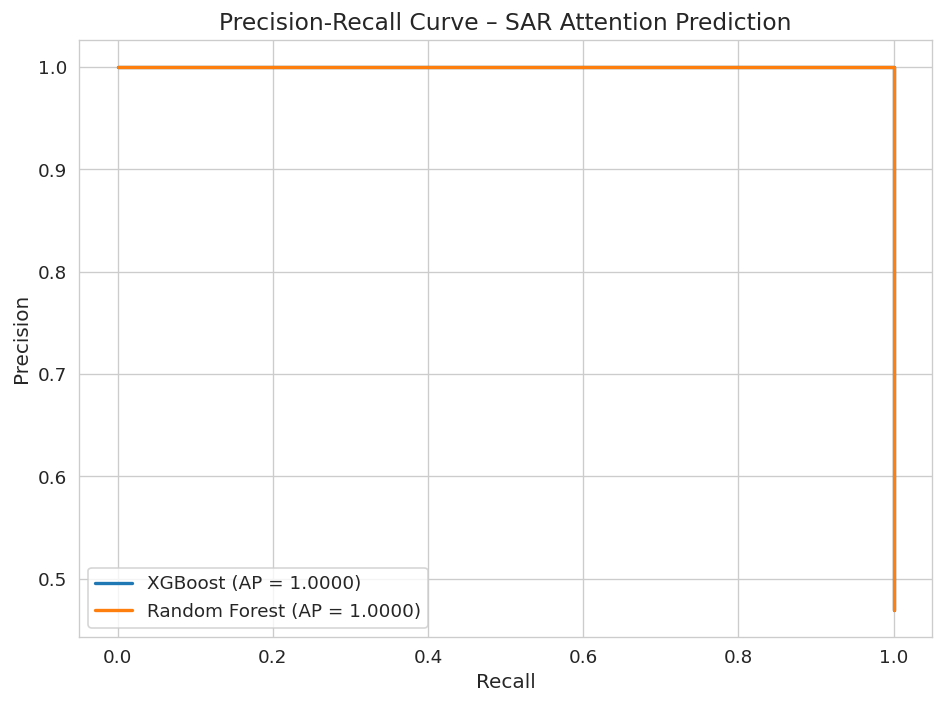

  📊 Precision‑Recall curve saved → precision_recall_curve.png

  STEP 14 : Generating Predictions & Risk Categories

  Prediction distribution:
predicted_label
0    263
1    237

  Risk category distribution:
risk_category
Low     263
High    237

  Preview (first 10 rows):

   risk_probability  predicted_label risk_category  actual_label
0            0.0054                0           Low             0
1            0.0055                0           Low             0
2            0.0058                0           Low             0
3            0.9941                1          High             1
4            0.0097                0           Low             0
5            0.9945                1          High             1
6            0.0055                0           Low             0
7            0.9943                1          High             1
8            0.9941                1          High             1
9            0.9944                1          High             1

  💾 Pred

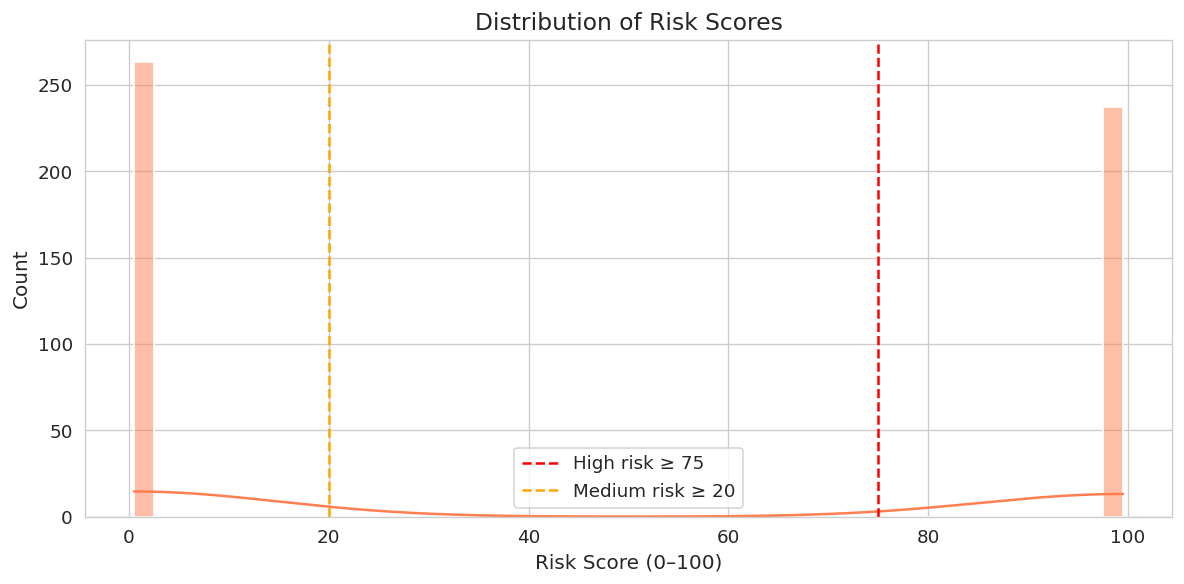

  📊 Risk score distribution saved → risk_score_distribution.png

  ✅  PIPELINE COMPLETE  –  SUMMARY

  Best Model          : XGBoost
  Accuracy            : 1.0000
  Precision           : 1.0000
  Recall              : 1.0000
  F1‑Score            : 1.0000
  ROC‑AUC             : 1.0000
  Avg Precision (PR)  : 1.0000
  CV ROC‑AUC (mean)   : 1.0000 ± 0.0000

  Outputs saved:
    • sar_predictions_output.csv
    • feature_importance.png
    • confusion_matrix.png
    • roc_curve.png
    • precision_recall_curve.png
    • risk_score_distribution.png



In [8]:
###############################################################################
#  SAR / AML Risk‑Prediction Pipeline  –  Production‑Quality
#  ─────────────────────────────────────────────────────────────────────────────
#  Target   : attention_required  (1 = SAR required, 0 = not required)
#  Model    : XGBoost (primary) with Random Forest comparison
#  Designed : Ready to run in Google Colab or any Python 3.8+ environment
###############################################################################

# ── 0. Install dependencies (Colab‑safe) ────────────────────────────────────
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import xgboost  # noqa: F401
except ImportError:
    _install("xgboost")

# ── 1. Imports ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})
sns.set_style("whitegrid")

###############################################################################
#                         CONFIGURATION
###############################################################################
# Path to the SAR dataset – update this if the file lives elsewhere.
DATASET_PATH = "sar_dataset.csv"

# Target column
TARGET = "attention_required"

# Columns to DROP – identifiers, free‑text, phone numbers, analyst PII
COLS_TO_DROP = [
    "sar_id",
    "customer_id",
    "customer_name",
    "account_number",
    "address",
    "analyst_name",
    "analyst_title",
    "analyst_phone",
    "contact_office",
    "branch_name",
    "explainability_notes",
    "supporting_evidence",
]

# Random seed for reproducibility
SEED = 42

# Risk‑category probability thresholds
HIGH_RISK_THRESHOLD  = 0.75
MED_RISK_THRESHOLD   = 0.20

###############################################################################
#  STEP 1 ─ DATA LOADING & INITIAL EXPLORATION
###############################################################################
print("=" * 70)
print("  STEP 1 : Loading Dataset")
print("=" * 70)

df = pd.read_csv(DATASET_PATH)

print(f"  Shape           : {df.shape}")
print(f"  Columns         : {df.columns.tolist()}")
print(f"\n  Target distribution:\n{df[TARGET].value_counts()}\n")
print(f"  Class balance   : {df[TARGET].value_counts(normalize=True).to_dict()}")
print(f"\n  Missing values (top 10):\n{df.isnull().sum().sort_values(ascending=False).head(10)}\n")

###############################################################################
#  STEP 2 ─ DATA CLEANING & PREPROCESSING
###############################################################################
print("=" * 70)
print("  STEP 2 : Data Cleaning & Preprocessing")
print("=" * 70)

# 2a. Drop non‑useful identifier / text columns
existing_drop = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=existing_drop, inplace=True)
print(f"  Dropped columns : {existing_drop}")

# 2b. Parse date columns & engineer temporal features
date_cols = [
    "filing_date",
    "date_of_birth",
    "activity_start_date",
    "activity_end_date",
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Derive useful temporal features
if "activity_start_date" in df.columns and "activity_end_date" in df.columns:
    df["activity_duration_days"] = (
        df["activity_end_date"] - df["activity_start_date"]
    ).dt.days

if "date_of_birth" in df.columns and "filing_date" in df.columns:
    df["customer_age_at_filing"] = (
        (df["filing_date"] - df["date_of_birth"]).dt.days / 365.25
    ).round(1)

# Drop raw date columns after feature extraction
raw_dates_to_drop = [c for c in date_cols if c in df.columns]
df.drop(columns=raw_dates_to_drop, inplace=True)
print(f"  Date‑derived features created & raw dates dropped.")

# 2c. Handle missing values
#   Numeric  → median imputation
#   Categorical → mode imputation (or 'Unknown')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove target from feature lists
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
if TARGET in categorical_cols:
    categorical_cols.remove(TARGET)

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown", inplace=True)

print(f"  Remaining missing values : {df.isnull().sum().sum()}")

# 2d. Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"  Label‑encoded {len(categorical_cols)} categorical columns.")
print(f"  Final feature matrix shape : {df.shape}")

###############################################################################
#  STEP 3 ─ FEATURE / TARGET SPLIT
###############################################################################
print("\n" + "=" * 70)
print("  STEP 3 : Feature / Target Split")
print("=" * 70)

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

feature_names = X.columns.tolist()
print(f"  Number of features : {len(feature_names)}")
print(f"  Features           : {feature_names}")

###############################################################################
#  STEP 4 ─ TRAIN / TEST SPLIT
###############################################################################
print("\n" + "=" * 70)
print("  STEP 4 : Train / Test Split (80 / 20, stratified)")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"  Train set : {X_train.shape}  |  Positive class: {y_train.sum()} / {len(y_train)}")
print(f"  Test  set : {X_test.shape}  |  Positive class: {y_test.sum()} / {len(y_test)}")

###############################################################################
#  STEP 5 ─ HANDLE CLASS IMBALANCE
###############################################################################
print("\n" + "=" * 70)
print("  STEP 5 : Class Imbalance Handling")
print("=" * 70)

imbalance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
print(f"  Minority / Majority ratio : {imbalance_ratio:.4f}")

# Compute scale_pos_weight for XGBoost (handles imbalance internally)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
print(f"  scale_pos_weight for XGBoost : {scale_pos_weight:.2f}")

# Also compute sample weights for Random Forest
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

###############################################################################
#  STEP 6 ─ FEATURE SCALING
###############################################################################
print("\n" + "=" * 70)
print("  STEP 6 : Feature Scaling (StandardScaler)")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names, index=X_test.index
)
print("  Scaling applied to train & test sets.")

###############################################################################
#  STEP 7 ─ MODEL TRAINING  (XGBoost – primary)
###############################################################################
print("\n" + "=" * 70)
print("  STEP 7 : Training XGBoost Classifier")
print("=" * 70)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50,
)
print("  ✅ XGBoost model trained.\n")

###############################################################################
#  STEP 7b ─ MODEL TRAINING  (Random Forest – comparison)
###############################################################################
print("=" * 70)
print("  STEP 7b : Training Random Forest Classifier (for comparison)")
print("=" * 70)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)

rf_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
print("  ✅ Random Forest model trained.\n")

###############################################################################
#  STEP 8 ─ MODEL EVALUATION
###############################################################################
print("=" * 70)
print("  STEP 8 : Model Evaluation")
print("=" * 70)

def evaluate_model(model, X_ts, y_ts, model_name="Model"):
    """Evaluate a classifier and print core metrics."""
    y_pred = model.predict(X_ts)
    y_prob = model.predict_proba(X_ts)[:, 1]

    acc   = accuracy_score(y_ts, y_pred)
    prec  = precision_score(y_ts, y_pred, zero_division=0)
    rec   = recall_score(y_ts, y_pred, zero_division=0)
    f1    = f1_score(y_ts, y_pred, zero_division=0)
    auc   = roc_auc_score(y_ts, y_prob)
    ap    = average_precision_score(y_ts, y_prob)

    print(f"\n  ── {model_name} ──")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision         : {prec:.4f}")
    print(f"  Recall            : {rec:.4f}")
    print(f"  F1‑Score          : {f1:.4f}")
    print(f"  ROC‑AUC           : {auc:.4f}")
    print(f"  Avg Precision (PR): {ap:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_ts, y_pred, target_names=["No SAR", "SAR Required"]))

    return y_pred, y_prob, {"accuracy": acc, "precision": prec, "recall": rec,
                            "f1": f1, "roc_auc": auc, "avg_precision": ap}

# Evaluate both models
xgb_pred, xgb_prob, xgb_metrics = evaluate_model(
    xgb_model, X_test_scaled, y_test, "XGBoost"
)

rf_pred, rf_prob, rf_metrics = evaluate_model(
    rf_model, X_test_scaled, y_test, "Random Forest"
)

# Select the best model based on ROC‑AUC
if xgb_metrics["roc_auc"] >= rf_metrics["roc_auc"]:
    best_model = xgb_model
    best_name  = "XGBoost"
    best_pred  = xgb_pred
    best_prob  = xgb_prob
    best_met   = xgb_metrics
else:
    best_model = rf_model
    best_name  = "Random Forest"
    best_pred  = rf_pred
    best_prob  = rf_prob
    best_met   = rf_metrics

print(f"\n  🏆 Best model selected : {best_name}  (ROC‑AUC = {best_met['roc_auc']:.4f})")

###############################################################################
#  STEP 9 ─ CROSS‑VALIDATION (best model)
###############################################################################
print("\n" + "=" * 70)
print("  STEP 9 : 5‑Fold Stratified Cross‑Validation")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(best_model, X_train_scaled, y_train, cv=cv,
                          scoring="roc_auc", n_jobs=-1)
print(f"  CV ROC‑AUC scores : {cv_auc.round(4)}")
print(f"  Mean ± Std        : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

###############################################################################
#  STEP 10 ─ FEATURE IMPORTANCE
###############################################################################
print("\n" + "=" * 70)
print("  STEP 10 : Feature Importance (Top 20)")
print("=" * 70)

if best_name == "XGBoost":
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feat_imp.head(20).to_string(index=False))

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(feat_imp))
sns.barplot(
    data=feat_imp.head(top_n),
    y="feature", x="importance",
    palette="viridis", ax=ax
)
ax.set_title(f"Top {top_n} Feature Importances ({best_name})")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 Feature importance plot saved → feature_importance.png")

###############################################################################
#  STEP 11 ─ CONFUSION MATRIX PLOT
###############################################################################
print("\n" + "=" * 70)
print("  STEP 11 : Confusion Matrix")
print("=" * 70)

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No SAR", "SAR Required"],
    yticklabels=["No SAR", "SAR Required"],
    ax=ax, linewidths=0.5, linecolor="gray"
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix – {best_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 Confusion matrix saved → confusion_matrix.png")

###############################################################################
#  STEP 12 ─ ROC CURVE
###############################################################################
print("\n" + "=" * 70)
print("  STEP 12 : ROC Curve")
print("=" * 70)

fig, ax = plt.subplots(figsize=(8, 6))

for name, probs in [("XGBoost", xgb_prob), ("Random Forest", rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="Random Baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve – SAR Attention Prediction")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 ROC curve saved → roc_curve.png")

###############################################################################
#  STEP 13 ─ PRECISION‑RECALL CURVE (important for imbalanced data)
###############################################################################
print("\n" + "=" * 70)
print("  STEP 13 : Precision‑Recall Curve")
print("=" * 70)

fig, ax = plt.subplots(figsize=(8, 6))

for name, probs in [("XGBoost", xgb_prob), ("Random Forest", rf_prob)]:
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, probs)
    ap_val = average_precision_score(y_test, probs)
    ax.plot(rec_vals, prec_vals, lw=2, label=f"{name} (AP = {ap_val:.4f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision‑Recall Curve – SAR Attention Prediction")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 Precision‑Recall curve saved → precision_recall_curve.png")

###############################################################################
#  STEP 14 ─ GENERATE PREDICTIONS WITH RISK CATEGORIES
###############################################################################
print("\n" + "=" * 70)
print("  STEP 14 : Generating Predictions & Risk Categories")
print("=" * 70)

# Predict on the FULL dataset (for output / downstream consumption)
X_full_scaled = pd.DataFrame(
    scaler.transform(X), columns=feature_names, index=X.index
)

full_probs = best_model.predict_proba(X_full_scaled)[:, 1]
full_preds = best_model.predict(X_full_scaled)

# Build risk categories
def assign_risk_category(prob):
    """Assign High / Medium / Low risk based on probability thresholds."""
    if prob >= HIGH_RISK_THRESHOLD:
        return "High"
    elif prob >= MED_RISK_THRESHOLD:
        return "Medium"
    else:
        return "Low"

results_df = pd.DataFrame({
    "risk_probability":  full_probs.round(4),
    "predicted_label":   full_preds,
    "risk_category":     [assign_risk_category(p) for p in full_probs],
    "actual_label":      y.values,
})

# Attach original index for traceability
results_df.index = df.index

print(f"\n  Prediction distribution:")
print(results_df["predicted_label"].value_counts().to_string())
print(f"\n  Risk category distribution:")
print(results_df["risk_category"].value_counts().to_string())
print(f"\n  Preview (first 10 rows):\n")
print(results_df.head(10).to_string())

###############################################################################
#  STEP 15 ─ EXPORT PREDICTIONS
###############################################################################
OUTPUT_PATH = "sar_predictions_output.csv"
results_df.to_csv(OUTPUT_PATH, index=False)
print(f"\n  💾 Predictions saved → {OUTPUT_PATH}")

###############################################################################
#  STEP 16 ─ RISK SCORE GENERATION (normalised 0–100)
###############################################################################
print("\n" + "=" * 70)
print("  STEP 16 : Risk Score Generation (0–100)")
print("=" * 70)

results_df["risk_score"] = (results_df["risk_probability"] * 100).round(1)

print(results_df[["risk_probability", "risk_score", "risk_category", "predicted_label"]].describe())

# Risk score distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(results_df["risk_score"], bins=50, kde=True, color="coral", ax=ax)
ax.axvline(HIGH_RISK_THRESHOLD * 100, color="red",   ls="--", lw=1.5, label=f"High risk ≥ {int(HIGH_RISK_THRESHOLD*100)}")
ax.axvline(MED_RISK_THRESHOLD  * 100, color="orange", ls="--", lw=1.5, label=f"Medium risk ≥ {int(MED_RISK_THRESHOLD*100)}")
ax.set_title("Distribution of Risk Scores")
ax.set_xlabel("Risk Score (0–100)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("risk_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 Risk score distribution saved → risk_score_distribution.png")

###############################################################################
#  STEP 17 ─ MODEL SUMMARY
###############################################################################
print("\n" + "=" * 70)
print("  ✅  PIPELINE COMPLETE  –  SUMMARY")
print("=" * 70)
print(f"""
  Best Model          : {best_name}
  Accuracy            : {best_met['accuracy']:.4f}
  Precision           : {best_met['precision']:.4f}
  Recall              : {best_met['recall']:.4f}
  F1‑Score            : {best_met['f1']:.4f}
  ROC‑AUC             : {best_met['roc_auc']:.4f}
  Avg Precision (PR)  : {best_met['avg_precision']:.4f}
  CV ROC‑AUC (mean)   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}

  Outputs saved:
    • sar_predictions_output.csv
    • feature_importance.png
    • confusion_matrix.png
    • roc_curve.png
    • precision_recall_curve.png
    • risk_score_distribution.png
""")
print("=" * 70)
